*Importing* Necessary Libraries


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,classification_report, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import cross_val_score, KFold
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import VarianceThreshold
from sklearn.datasets import load_iris
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

model_metrics = {}

**Importing Dataset:** importing the selected Dataset for the Project

In [ ]:
df = pd.read_csv('/content/dataset_sdn.csv') #Reading the Dataset from the File
df.head(1000).to_csv('Preprocessed_data.csv', index=False) #exporting the first 1000 rows
print(df.info()) #Displaying Information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104345 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dt              104345 non-null  int64  
 1   switch          104345 non-null  int64  
 2   sourceIP        104345 non-null  object 
 3   destinationIP   104345 non-null  object 
 4   packetCount     104345 non-null  int64  
 5   byteCount       104345 non-null  int64  
 6   duration        104345 non-null  int64  
 7   duration_nsec   104345 non-null  int64  
 8   total_duration  104345 non-null  float64
 9   flows           104345 non-null  int64  
 10  packetins       104345 non-null  int64  
 11  pktperflow      104345 non-null  int64  
 12  byteperflow     104345 non-null  int64  
 13  pktrate         104345 non-null  int64  
 14  Pairflow        104345 non-null  int64  
 15  Protocol        104345 non-null  object 
 16  port_no         104345 non-null  int64  
 17  tx_bytes  

Preprocessing: Dropping Nulls and Duplicates

In [ ]:
df.isnull().sum() #checks for nulls on the dataset
df = df.dropna() #Drops nulls
df.info() #displays info after dropping

<class 'pandas.core.frame.DataFrame'>
Index: 103839 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dt              103839 non-null  int64  
 1   switch          103839 non-null  int64  
 2   sourceIP        103839 non-null  object 
 3   destinationIP   103839 non-null  object 
 4   packetCount     103839 non-null  int64  
 5   byteCount       103839 non-null  int64  
 6   duration        103839 non-null  int64  
 7   duration_nsec   103839 non-null  int64  
 8   total_duration  103839 non-null  float64
 9   flows           103839 non-null  int64  
 10  packetins       103839 non-null  int64  
 11  pktperflow      103839 non-null  int64  
 12  byteperflow     103839 non-null  int64  
 13  pktrate         103839 non-null  int64  
 14  Pairflow        103839 non-null  int64  
 15  Protocol        103839 non-null  object 
 16  port_no         103839 non-null  int64  
 17  tx_bytes       

In [ ]:
df = df.drop_duplicates() #drops duplicates
df.info() # Displays info after dropping all duplicates

<class 'pandas.core.frame.DataFrame'>
Index: 98748 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dt              98748 non-null  int64  
 1   switch          98748 non-null  int64  
 2   sourceIP        98748 non-null  object 
 3   destinationIP   98748 non-null  object 
 4   packetCount     98748 non-null  int64  
 5   byteCount       98748 non-null  int64  
 6   duration        98748 non-null  int64  
 7   duration_nsec   98748 non-null  int64  
 8   total_duration  98748 non-null  float64
 9   flows           98748 non-null  int64  
 10  packetins       98748 non-null  int64  
 11  pktperflow      98748 non-null  int64  
 12  byteperflow     98748 non-null  int64  
 13  pktrate         98748 non-null  int64  
 14  Pairflow        98748 non-null  int64  
 15  Protocol        98748 non-null  object 
 16  port_no         98748 non-null  int64  
 17  tx_bytes        98748 non-null  int

**Preproceesing:** This code checks for the 15 most important features

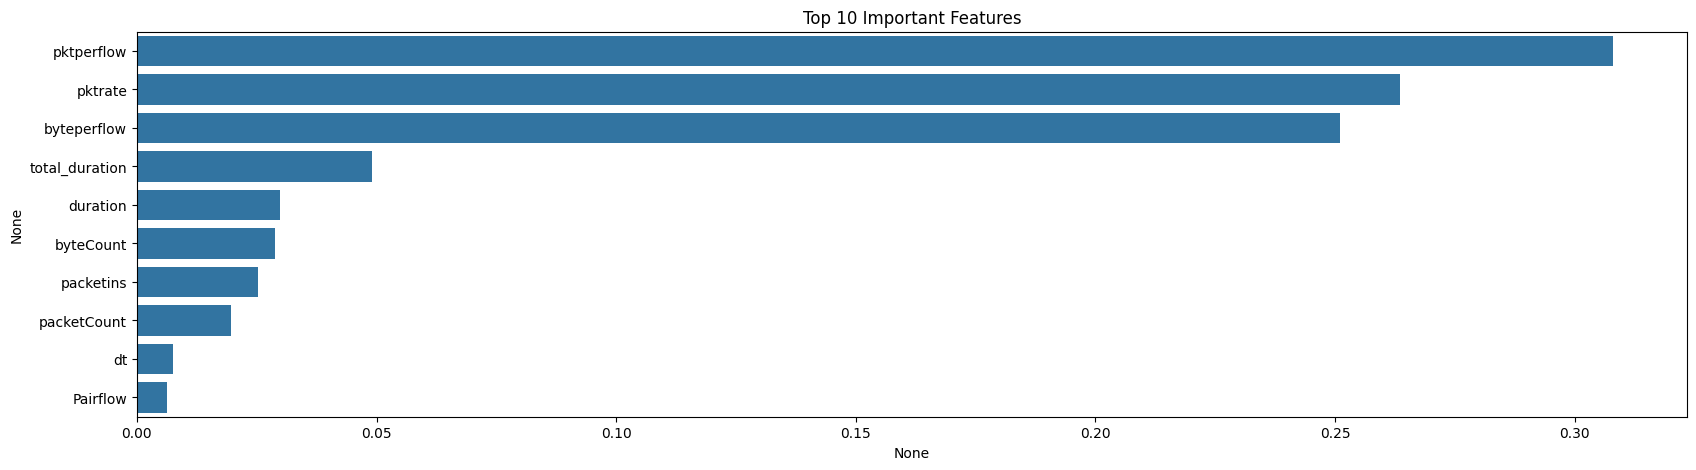

In [ ]:
Xtemp = df.drop('label', axis=1)
ytemp = df['label']

X_numeric = Xtemp.select_dtypes(include=['number'])

# 1. Remove low-variance features
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_numeric)
selected_columns_var = X_numeric.columns[selector.get_support()]

Xtemp = pd.DataFrame(X_var, columns=selected_columns_var)


# 2. Random Forest for classifying the important features

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(Xtemp, ytemp)

# Get the features by getting the variance (from high to low )
feat_importances = pd.Series(model.feature_importances_, index=Xtemp.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# 3. Plotting the top features
plt.figure(figsize=(20,5))
sns.barplot(x=feat_importances[:10], y=feat_importances.index[:10])
plt.title('Top 10 Important Features')
plt.show()


**Preproceesing:** Extracting important features for model training and testing

In [ ]:
df = df.drop(columns=['switch', 'sourceIP', 'destinationIP', 'duration_nsec', 'flows',
    'Pairflow', 'Protocol', 'port_no', 'rx_bytes', 'tx_kbps', 'rx_kbps',
    'tot_kbps']) #dropping the Features that are not practical for training this model
df.info() #Displays the Dataset after dropping the Unnecessary features


<class 'pandas.core.frame.DataFrame'>
Index: 37310 entries, 0 to 42906
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dt              37310 non-null  int64  
 1   packetCount     37310 non-null  int64  
 2   byteCount       37310 non-null  int64  
 3   duration        37310 non-null  int64  
 4   total_duration  37310 non-null  float64
 5   packetins       37310 non-null  int64  
 6   pktperflow      37310 non-null  int64  
 7   byteperflow     37310 non-null  int64  
 8   pktrate         37310 non-null  int64  
 9   tx_bytes        37310 non-null  int64  
 10  label           37310 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 3.4 MB


**Preprocessing:** Dealing with outliers


In [ ]:
outlierscale = StandardScaler()
scores = outlierscale.fit_transform(df)
normal = (np.abs(scores) < 3 ).all(axis=1)
df = df[normal]
df.info() #Displays the Dataset after dropping the outliers

<class 'pandas.core.frame.DataFrame'>
Index: 35770 entries, 0 to 42906
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dt              35770 non-null  int64  
 1   packetCount     35770 non-null  int64  
 2   byteCount       35770 non-null  int64  
 3   duration        35770 non-null  int64  
 4   total_duration  35770 non-null  float64
 5   packetins       35770 non-null  int64  
 6   pktperflow      35770 non-null  int64  
 7   byteperflow     35770 non-null  int64  
 8   pktrate         35770 non-null  int64  
 9   tx_bytes        35770 non-null  int64  
 10  label           35770 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 3.3 MB


**Preproceesing:** Dropping null rows

In [ ]:
df.isnull().sum() #checks for nulls on the dataset
df = df.dropna() #Drops nulls
df.info() #displays info after dropping

<class 'pandas.core.frame.DataFrame'>
Index: 35770 entries, 0 to 42906
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dt              35770 non-null  int64  
 1   packetCount     35770 non-null  int64  
 2   byteCount       35770 non-null  int64  
 3   duration        35770 non-null  int64  
 4   total_duration  35770 non-null  float64
 5   packetins       35770 non-null  int64  
 6   pktperflow      35770 non-null  int64  
 7   byteperflow     35770 non-null  int64  
 8   pktrate         35770 non-null  int64  
 9   tx_bytes        35770 non-null  int64  
 10  label           35770 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 3.3 MB


**Preproceesing:** Dropping Duplicate rows

In [ ]:
df = df.drop_duplicates() #drops duplicates
df.info() # Displays info after dropping all duplicates

<class 'pandas.core.frame.DataFrame'>
Index: 29540 entries, 0 to 42906
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dt              29540 non-null  int64  
 1   packetCount     29540 non-null  int64  
 2   byteCount       29540 non-null  int64  
 3   duration        29540 non-null  int64  
 4   total_duration  29540 non-null  float64
 5   packetins       29540 non-null  int64  
 6   pktperflow      29540 non-null  int64  
 7   byteperflow     29540 non-null  int64  
 8   pktrate         29540 non-null  int64  
 9   tx_bytes        29540 non-null  int64  
 10  label           29540 non-null  float64
dtypes: float64(2), int64(9)
memory usage: 2.7 MB


**Preproceesing:** Replacing the labels: Benign and DrDos_UDP to Binary values 1 and 0

In [ ]:
#df['Label'] = df['Label'].replace({'Benign':0, 'Syn':1}) #changing the label feature to binary 0 and 1 for training purposes
#df.info()#Displays the info and here we can see that the Label changed from an Object type to an int64 type

**Preproceesing:** splitting the data set into Labels and other features

In [ ]:
x = df.drop(columns=['label']) #seprating the dataset from the label
y = df['label']#seprating the dataset from the label

**Preproceesing:**Splitting data into test and train samples

In [ ]:
#spliting the dataset into training and testing data the ratio used is 80% training and 20 testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**Preproceesing:** Standraizing the dataset with StandardScaler

In [ ]:
#normalizing the data for Logistic Regression, SVM and GuassianNB
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)


**Preproceesing:** Due to Imbalance we used undersampler to balance the Dataset

Bengin Before sampling: 10263
DDOS Before sampling: 13369


Bengin After sampling: 10263
DDOS After sampling: 10263


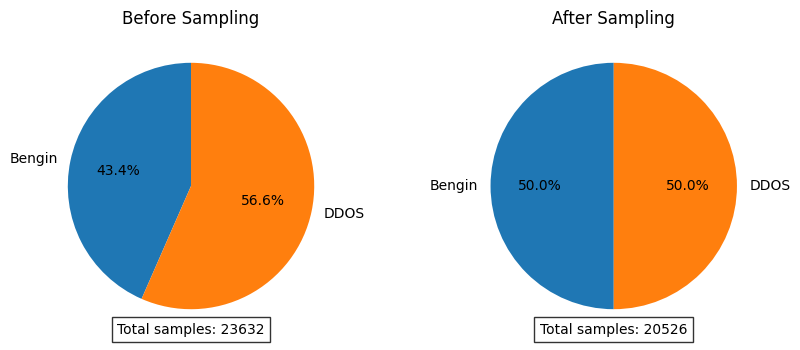

In [ ]:
# due to imbalance we need to resample the data and the best way is to either undersample it or Oversample
undersampler = RandomUnderSampler(random_state=42)
x_train_res, y_train_res = undersampler.fit_resample(x_train, y_train)
x_train_res_sc, y_train_res_sc = undersampler.fit_resample(x_train_sc, y_train)


# these are to count how many entries we have before and after sampling
before = Counter(y_train)
after = Counter(y_train_res)

beforeList = {'Bengin':before[0], 'DDOS':before[1]} # creating a list for Before sampling
afterList = {'Bengin':after[0], 'DDOS':after[1]} # creating a list for after sampling

#displaying the outputs
print(f"Bengin Before sampling: {beforeList['Bengin']}")
print(f"DDOS Before sampling: {beforeList['DDOS']}")
print('\n')
print(f"Bengin After sampling: {afterList['Bengin']}")
print(f"DDOS After sampling: {afterList['DDOS']}")

#plotting a pie chart to see the effectivness of the sampling
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].set_title('Before Sampling')
ax[0].pie([beforeList['Bengin'], beforeList['DDOS']], labels=['Bengin', 'DDOS'], autopct='%1.1f%%', startangle=90)
ax[0].text(0, -1.2, f"Total samples: {sum(beforeList.values())}",
        ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
ax[1].pie([afterList['Bengin'], afterList['DDOS']], labels=['Bengin', 'DDOS'], autopct='%1.1f%%', startangle=90)
ax[1].set_title('After Sampling')
ax[1].text(0, -1.2, f"Total samples: {sum(afterList.values())}",
        ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.show()



In [ ]:
Preprocessed_df = pd.DataFrame(x_train_res, columns=x_train.columns)  # turing the samples into a dataframe
Preprocessed_df['Label'] = y_train_res  # Adding the label column
Preprocessed_df.head(1000).to_csv('Preprocessed_data.csv', index=False)

**Preproccessing:** preparing data for cross validation

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

**Model training:** For this project we used RandomForest,Logistic Regression, Decision Tree, SVM and Naive Bayes


In [ ]:
#Training a random forest model
Randfor = RandomForestClassifier(n_estimators=100 , max_depth=5, random_state=42)
Randfor.fit(x_train_res, y_train_res)
y_pred = Randfor.predict(x_test)

#testing Accuracy, Precision, Recall and F1 score
rf_accuracy = accuracy_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
Randfor_cm = confusion_matrix(y_test, y_pred)
rf_cross = cross_val_score(Randfor, x_train_res, y_train_res, cv=kfold)

print(f"Accuracy Score: {rf_accuracy*100:.2f}%")
print(f"Precision Score: {rf_precision*100:.2f}%")
print(f"Recall Score: {rf_recall*100:.2f}%")
print(f"F1 Score: {rf_f1*100:.2f}%")
print(f"Cross validation scores: {rf_cross}")
print('\n')
print(classification_report(y_test, y_pred))

#creating a dictionary so we save all data for later comparsion
model_metrics['Random Forest'] = {
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1': rf_f1
}

Accuracy Score: 99.76%
Precision Score: 99.58%
Recall Score: 100.00%
F1 Score: 99.79%
Cross validation scores: [0.99805163 0.99634592 0.99780755 0.99829476 0.99756395]


              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      2583
         1.0       1.00      1.00      1.00      3325

    accuracy                           1.00      5908
   macro avg       1.00      1.00      1.00      5908
weighted avg       1.00      1.00      1.00      5908



In [ ]:
#Taining Logistic Regression model
LogReg = LogisticRegression(penalty='l2', C=0.2,solver='lbfgs', random_state=42)
LogReg.fit(x_train_res_sc, y_train_res_sc)
y_pred = LogReg.predict(x_test_sc)

#testing Accuracy, Precision, Recall and F1 score
LogReg_accuracy = accuracy_score(y_test, y_pred)
LogReg_precision = precision_score(y_test, y_pred)
LogReg_recall = recall_score(y_test, y_pred)
LogReg_f1 = f1_score(y_test, y_pred)
LogReg_cm = confusion_matrix(y_test, y_pred)
LogReg_cross = cross_val_score(LogReg, x_train_res_sc, y_train_res_sc, cv=kfold)

print(f"Accuracy Score: {LogReg_accuracy*100:.2f}%")
print(f"Precision Score: {LogReg_precision*100:.2f}%")
print(f"Recall Score: {LogReg_recall*100:.2f}%")
print(f"F1 Score: {LogReg_f1*100:.2f}%")
print(f"Cross Validation scores: {LogReg_cross}")
print('\n')
print(classification_report(y_test, y_pred))
#adding the model on dictionary to save all data for later comparsion
model_metrics['Logistic Regression'] = {
    'accuracy': LogReg_accuracy,
    'precision': LogReg_precision,
    'recall': LogReg_recall,
    'f1': LogReg_f1
}

Accuracy Score: 92.04%
Precision Score: 91.49%
Recall Score: 94.68%
F1 Score: 93.05%
Cross Validation scores: [0.91134925 0.90694275 0.91181486 0.90231425 0.90694275]


              precision    recall  f1-score   support

         0.0       0.93      0.89      0.91      2583
         1.0       0.91      0.95      0.93      3325

    accuracy                           0.92      5908
   macro avg       0.92      0.92      0.92      5908
weighted avg       0.92      0.92      0.92      5908



In [ ]:
#Taining Decision Tree model
DesTree =DecisionTreeClassifier(criterion='gini' , max_depth=5, random_state=42)
DesTree.fit(x_train_res, y_train_res)
y_pred = DesTree.predict(x_test)

#testing Accuracy, Precision, Recall and F1 score
DesTree_accuracy = accuracy_score(y_test, y_pred)
DesTree_precision = precision_score(y_test, y_pred)
DesTree_recall = recall_score(y_test, y_pred)
DesTree_f1 = f1_score(y_test, y_pred)
DesTree_cm = confusion_matrix(y_test, y_pred)
DesTree_cross = cross_val_score(DesTree, x_train_res, y_train_res, cv=kfold)

print(f"Accuracy Score: {DesTree_accuracy*100:.2f}%")
print(f"Precision Score: {DesTree_precision*100:.2f}%")
print(f"Recall Score: {DesTree_recall*100:.2f}%")
print(f"F1 Score: {DesTree_f1*100:.2f}%")
print(f"Cross validation score: {DesTree_cross}")
print('\n')
print(classification_report(y_test, y_pred))

#adding the model on dictionary to save all data for later comparsion
model_metrics['Decision Tree'] = {
    'accuracy': DesTree_accuracy,
    'precision': DesTree_precision,
    'recall': DesTree_recall,
    'f1': DesTree_f1
}

Accuracy Score: 99.93%
Precision Score: 100.00%
Recall Score: 99.88%
F1 Score: 99.94%
Cross validation score: [0.99878227 0.99634592 0.99878197 0.99926918 0.99439708]


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2583
         1.0       1.00      1.00      1.00      3325

    accuracy                           1.00      5908
   macro avg       1.00      1.00      1.00      5908
weighted avg       1.00      1.00      1.00      5908



In [ ]:
#Taining SVM model with sigmoid kernel
SVM = SVC(kernel='poly', random_state=42)
SVM.fit(x_train_res_sc, y_train_res_sc)
y_pred = SVM.predict(x_test_sc)

#testing Accuracy, Precision, Recall and F1 score
svm_accuracy = accuracy_score(y_test, y_pred)
svm_precision = precision_score(y_test, y_pred)
svm_recall = recall_score(y_test, y_pred)
svm_f1 = f1_score(y_test, y_pred)
SVM_cm = confusion_matrix(y_test, y_pred)
svm_cross = cross_val_score(SVM, x_train_res_sc, y_train_res_sc, cv=kfold)


print(f"Accuracy Score: {svm_accuracy*100:.2f}%")
print(f"Precision Score: {svm_precision*100:.2f}%")
print(f"Recall Score: {svm_recall*100:.2f}%")
print(f"F1 Score: {svm_f1*100:.2f}%")
print(f"Cross validation scores:{svm_cross}")
print('\n')
print(classification_report(y_test, y_pred))

#adding the model on dictionary to save all data for later comparsion
model_metrics['SVM'] = {
    'accuracy': svm_accuracy,
    'precision': svm_precision,
    'recall': svm_recall,
    'f1': svm_f1
}

Accuracy Score: 99.12%
Precision Score: 98.95%
Recall Score: 99.49%
F1 Score: 99.22%
Cross validation scores:[0.98295178 0.98221681 0.98270402 0.98392205 0.98489647]


              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      2583
         1.0       0.99      0.99      0.99      3325

    accuracy                           0.99      5908
   macro avg       0.99      0.99      0.99      5908
weighted avg       0.99      0.99      0.99      5908



In [ ]:
#Taining GaussianNB(Naive Bayes) model
naive = GaussianNB()
naive.fit(x_train_res_sc, y_train_res_sc)
y_pred = naive.predict(x_test_sc)

#testing Accuracy, Precision, Recall and F1 score
naive_accuracy = accuracy_score(y_test, y_pred)
naive_precision = precision_score(y_test, y_pred)
naive_recall = recall_score(y_test, y_pred)
naive_f1 = f1_score(y_test, y_pred)
naive_cm = confusion_matrix(y_test, y_pred)
naive_cross = cross_val_score(naive, x_train_res_sc, y_train_res_sc, cv=kfold)

print(f"Accuracy Score: {naive_accuracy*100:.2f}%")
print(f"Precision Score: {naive_precision*100:.2f}%")
print(f"Recall Score: {naive_recall*100:.2f}%")
print(f"F1 Score: {naive_f1*100:.2f}%")
print(f"Cross validation scores: {naive_cross}")
print('\n')
print(classification_report(y_test, y_pred))

#adding the model on dictionary to save all data for later comparsion
model_metrics['Naive Bayes'] = {
    'accuracy': naive_accuracy,
    'precision': naive_precision,
    'recall': naive_recall,
    'f1': naive_f1
}

Accuracy Score: 85.39%
Precision Score: 90.39%
Recall Score: 82.86%
F1 Score: 86.46%
Cross validation scores: [0.86264004 0.85992692 0.85676005 0.85286236 0.85773447]


              precision    recall  f1-score   support

         0.0       0.80      0.89      0.84      2583
         1.0       0.90      0.83      0.86      3325

    accuracy                           0.85      5908
   macro avg       0.85      0.86      0.85      5908
weighted avg       0.86      0.85      0.85      5908



Text(0.5, 1.0, 'Confusion matrix for GaussianNB(Naive Bayes)')

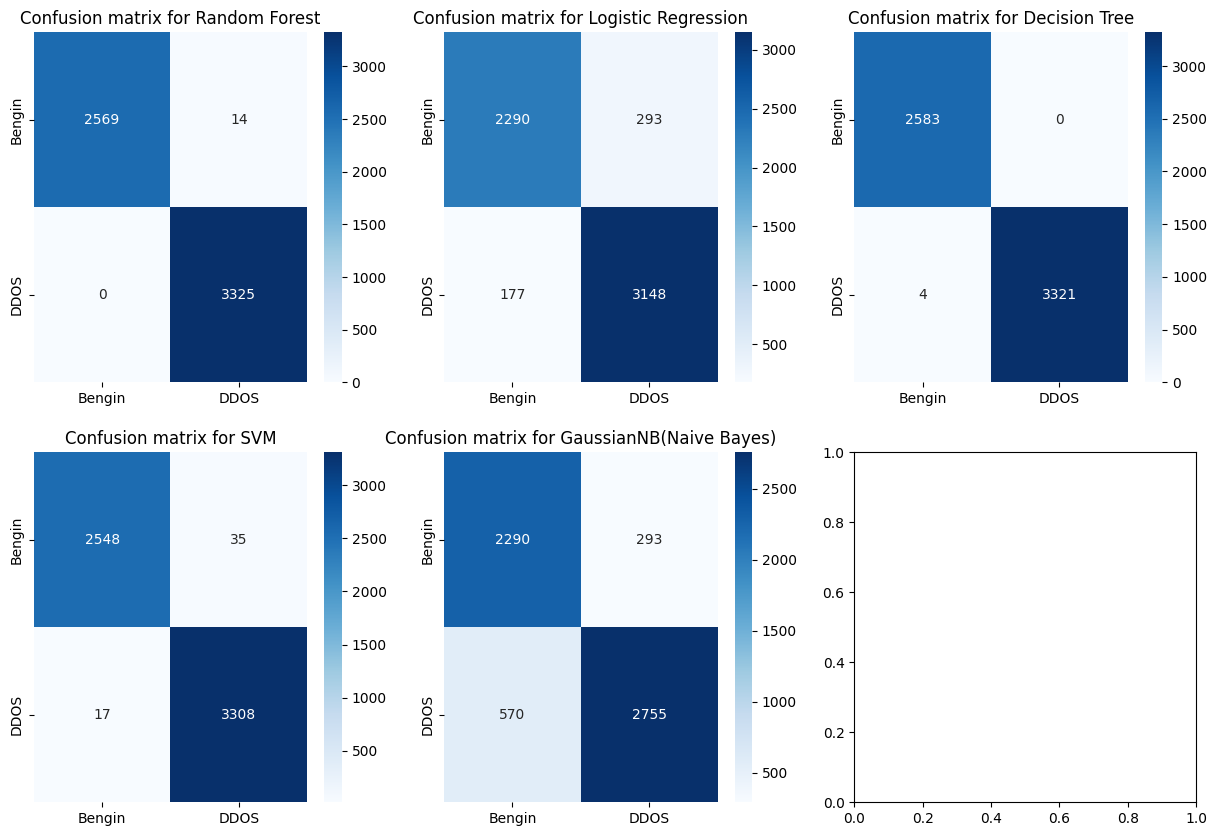

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns
sns.heatmap(Randfor_cm, annot=True, fmt='d', xticklabels=['Bengin','DDOS'], yticklabels=['Bengin','DDOS'], cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion matrix for Random Forest')

sns.heatmap(LogReg_cm, annot=True, fmt='d', xticklabels=['Bengin','DDOS'], yticklabels=['Bengin','DDOS'], cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Confusion matrix for Logistic Regression')

sns.heatmap(DesTree_cm, annot=True, fmt='d', xticklabels=['Bengin','DDOS'], yticklabels=['Bengin','DDOS'], cmap='Blues', ax=axes[0, 2])
axes[0, 2].set_title('Confusion matrix for Decision Tree')

sns.heatmap(SVM_cm, annot=True, fmt='d', xticklabels=['Bengin','DDOS'], yticklabels=['Bengin','DDOS'], cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Confusion matrix for SVM')

sns.heatmap(naive_cm, annot=True, fmt='d', xticklabels=['Bengin','DDOS'], yticklabels=['Bengin','DDOS'], cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Confusion matrix for GaussianNB(Naive Bayes)')

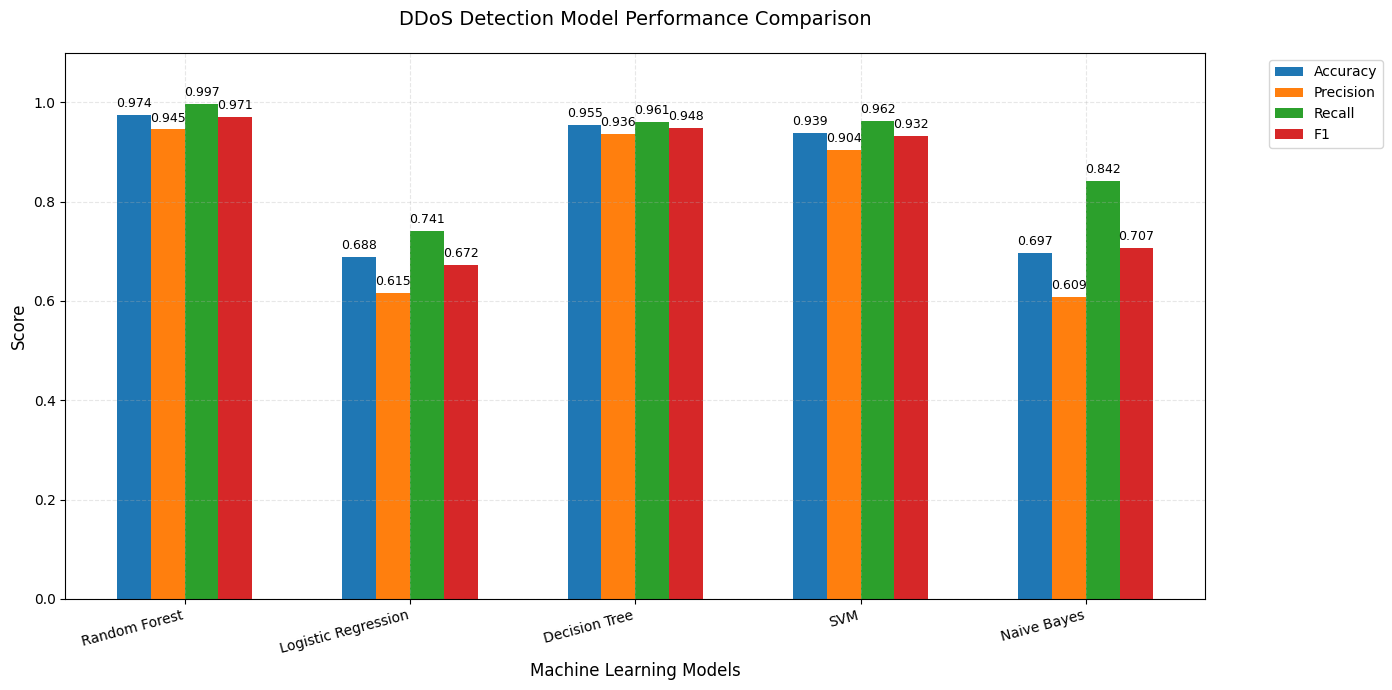

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
models = list(model_metrics.keys())

plt.figure(figsize=(14, 7))
width = 0.15
x = np.arange(len(models))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    values = [model_metrics[model][metric] for model in models]
    plt.bar(x + i*width, values, width, color=colors[i], label=metric.capitalize())

plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('DDoS Detection Model Performance Comparison', fontsize=14, pad=20)
plt.xticks(x + width*1.5, models, rotation=15, ha='right')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

for i, model in enumerate(models):
    for j, metric in enumerate(metrics):
        value = model_metrics[model][metric]
        plt.text(x[i] + j*width, value + 0.01, f'{value:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()